In [2]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load the dataset
df = pd.read_csv("C:/Users/JOHN EDEOGHON/OneDrive/Documents/E.EdeoghonCOS102/week-4/Project 2/titanic.csv")

# 3. Quick overview
print("First 5 rows:")
print(df.head())

print("\nDataset info:")
print(df.info())

print("\nMissing values before cleaning:")
print(df.isnull().sum())

print("\nBasic statistics:")
print(df.describe())

# 4. Data Cleaning Steps

# Check for duplicates
print(f"\nDuplicates before: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Duplicates after: {df.duplicated().sum()}")

# Handle missing values

# Age: Fill missing ages with median (less affected by outliers than mean)
df['Age'] = df['Age'].fillna(df['Age'].median())

# Cabin: Too many missing values (~77%), better to drop or create "Unknown" category
# Let's create a new column 'Has_Cabin' for analysis
df['Has_Cabin'] = df['Cabin'].notna().astype(int)
# Then drop original Cabin column (or keep if you want)
df = df.drop('Cabin', axis=1)

# Embarked: Only 2 missing values, fill with mode (most common port)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Fare: No missing values, but check for zeros or outliers
# Replace 0 fare with median fare (excluding zeros)
median_fare = df[df['Fare'] > 0]['Fare'].median()
df['Fare'] = df['Fare'].replace(0, median_fare)

# 5. Remove unrealistic outliers (optional but recommended)

# Age: Remove ages > 100 (none in Titanic, but good practice)
df = df[df['Age'] <= 100]

# Fare: Remove extreme outliers (above 99th percentile)
fare_99 = df['Fare'].quantile(0.99)
df = df[df['Fare'] <= fare_99]

# 6. Create useful new features

# Family size (SibSp + Parch + self)
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1

# Is alone? (Family_Size == 1)
df['Is_Alone'] = (df['Family_Size'] == 1).astype(int)

# Title extracted from Name (optional but useful)
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# Group rare titles
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 
                                    'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

# 7. Convert categorical variables to proper types

# Convert 'Sex' to numeric (0=male, 1=female)
df['Sex_Code'] = df['Sex'].map({'male': 0, 'female': 1})

# Convert 'Embarked' to numeric (S=0, C=1, Q=2)
df['Embarked_Code'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# 8. Verify cleaning was successful
print("\n" + "="*50)
print("Missing values after cleaning:")
print(df.isnull().sum())

print(f"\nDataset shape after cleaning: {df.shape}")

print("\nFirst 5 rows after cleaning:")
print(df.head())

# 9. Save cleaned data
df.to_csv('titanic_cleaned.csv', index=False)
print("\nCleaned data saved to 'titanic_cleaned.csv'")

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

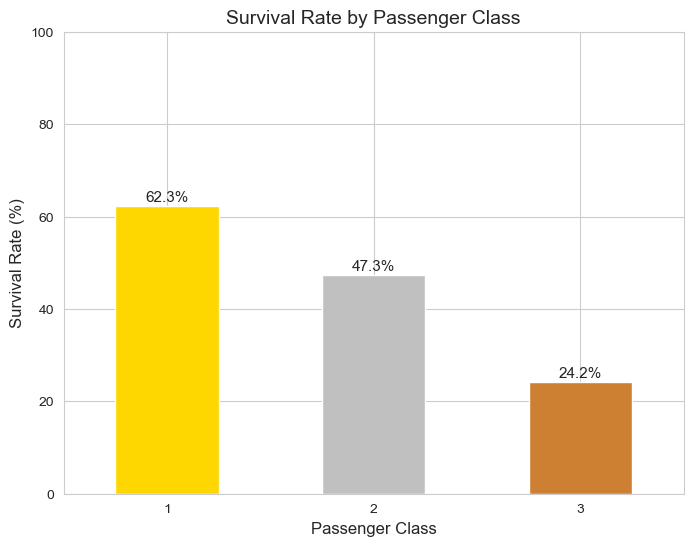

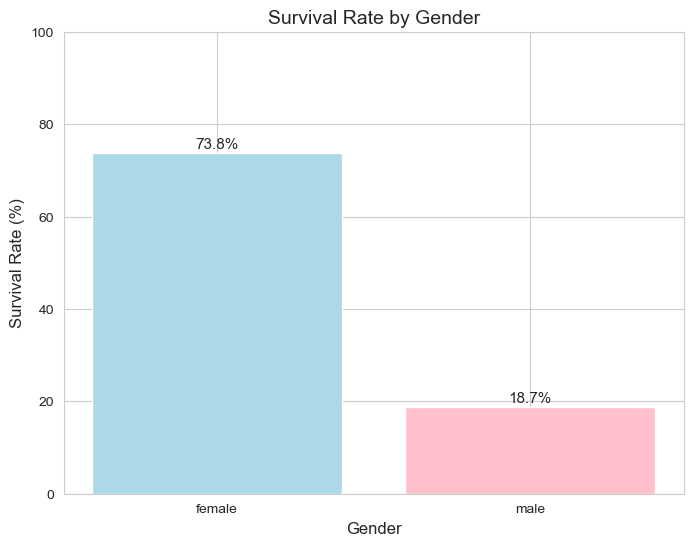

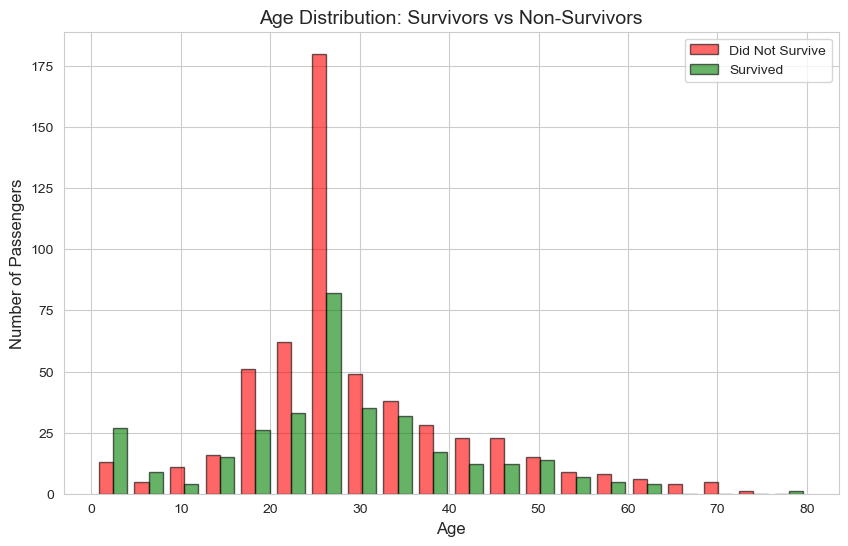

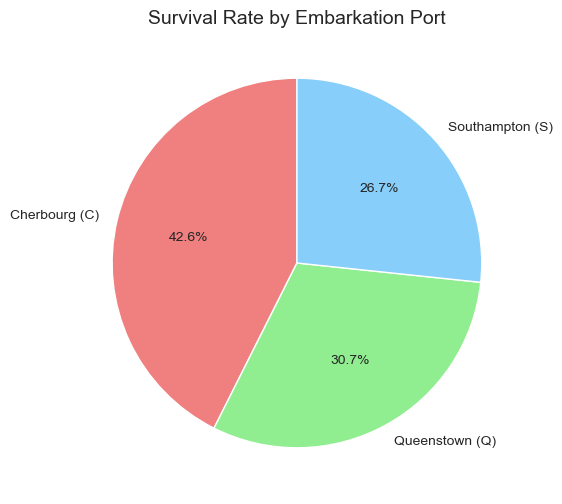

In [3]:
# Set style for better looking plots
sns.set_style("whitegrid")

# Visualization 1: Survival rate by passenger class
plt.figure(figsize=(8,6))
survival_by_class = df.groupby('Pclass')['Survived'].mean() * 100
survival_by_class.plot(kind='bar', color=['gold', 'silver', '#cd7f32'])
plt.title('Survival Rate by Passenger Class', fontsize=14)
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Survival Rate (%)', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 100)
for i, v in enumerate(survival_by_class):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11)
plt.show()

# Insight: First class had highest survival rate (~63%), third class lowest (~24%)
# because first class passengers were closer to lifeboats and given priority

# Visualization 2: Survival rate by gender
plt.figure(figsize=(8,6))
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100
colors = ['lightblue', 'pink']
bars = plt.bar(survival_by_sex.index, survival_by_sex.values, color=colors)
plt.title('Survival Rate by Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Survival Rate (%)', fontsize=12)
plt.ylim(0, 100)
for bar, rate in zip(bars, survival_by_sex.values):
    plt.text(bar.get_x() + bar.get_width()/2, rate + 1, f'{rate:.1f}%', 
             ha='center', fontsize=11)
plt.show()

# Insight: Women had ~74% survival rate vs men ~19% survival rate
# Due to "women and children first" evacuation policy

# Visualization 3: Age distribution of survivors vs non-survivors
plt.figure(figsize=(10,6))
plt.hist([df[df['Survived']==0]['Age'], df[df['Survived']==1]['Age']], 
         bins=20, label=['Did Not Survive', 'Survived'], 
         color=['red', 'green'], alpha=0.6, edgecolor='black')
plt.title('Age Distribution: Survivors vs Non-Survivors', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.legend()
plt.show()

# Insight: Children (under 10) had high survival rate, young adults (20-30) had mixed outcomes
# Elderly passengers (60+) had lower survival rates

# Bonus Visualization 4: Survival by embarkation port
plt.figure(figsize=(8,6))
survival_by_embarked = df.groupby('Embarked')['Survived'].mean() * 100
plt.pie(survival_by_embarked.values, labels=['Cherbourg (C)', 'Queenstown (Q)', 'Southampton (S)'],
        autopct='%1.1f%%', colors=['lightcoral', 'lightgreen', 'lightskyblue'], startangle=90)
plt.title('Survival Rate by Embarkation Port', fontsize=14)
plt.show()

# Insight: Passengers from Cherbourg had highest survival rate (55%)
# Southampton passengers had lowest (34%) - possibly due to more third class passengers

First visualisation: The first passenger class has the highest survival rate
Second visualisation: Females have a higher survival rate than men
Third visualisation: The ages with the most non survivors is between the ages of 20 and 30
Fourth visualisation: Cherbourgh had the highest survival rate by Embarkation Port